In [ ]:

# BOX COX TRANSFORMATION
# Box Cox transformation is a power transformation technique that is used to stabilize the variance and make the data more normally distributed. It is defined as:
# y(λ) = (y^λ - 1) / λ, if λ ≠ 0
# y(λ) = log(y), if λ = 0


# Lambda can be calculated either ith MAximum Likelihood or baysean approach. We will be using maximum likelihood approach to calculate lambda.

# STRICTLY POSITIVE DATA ONLY IN BOX COX TRANSFORMATION
# YEO-JOHN TRANSFORMATION
# Yeojohn transformation is a power transformation technique that is used to stabilize the variance and make the data more normally distributed. It is defined as:
   
# Yeojohn transformation can be applied to data that contains zero or negative values. It is a generalization of the Box Cox transformation and can be used when the data contains zero or negative values.
# by default in both tranformation standardization is done after transformation but we can also do it before transformation. It is always better to do standardization before transformation as it will make the data more normally distributed and will also make the data more suitable for transformation.

# ONCE LAMBDA IS CALCULATED FOR EVERY COLUMN < EACH VALUE IN THAT COLUMN IS RAISED TO THE POWER OF LAMBDA >
# LAMBDA CAN BE CALCULATED FOR EVERY COLUMN SEPARATELY OR FOR ALL COLUMNS TOGETHER. IT IS BETTER TO CALCULATE LAMBDA FOR EVERY COLUMN SEPARATELY AS IT WILL MAKE THE DATA MORE NORMALLY DISTRIBUTED.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [3]:
df = pd.read_csv('concrete_data.csv')


In [4]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
df.shape

(1030, 9)

In [6]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [7]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
X = df.drop(columns=['Strength'])
y = df.iloc[:, -1]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
#Applying linear regression withot any transformation
clf1 = LinearRegression()
clf1.fit(X_train, y_train)
y_pred = clf1.predict(X_test)
print("R2 score without transformation: ", r2_score(y_test, y_pred))

R2 score without transformation:  0.6275531792314848


In [12]:
np.mean(cross_val_score(clf1, X, y, cv=10, scoring='r2'))

np.float64(0.27820729160873753)

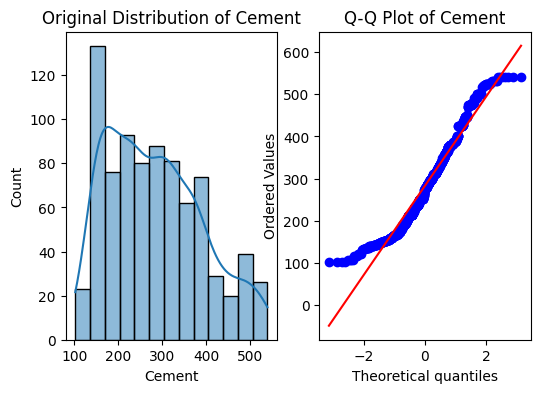

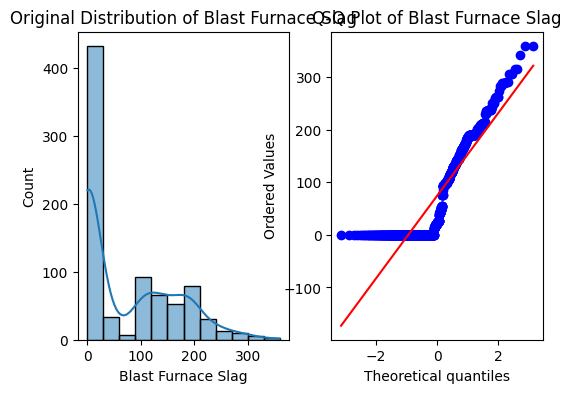

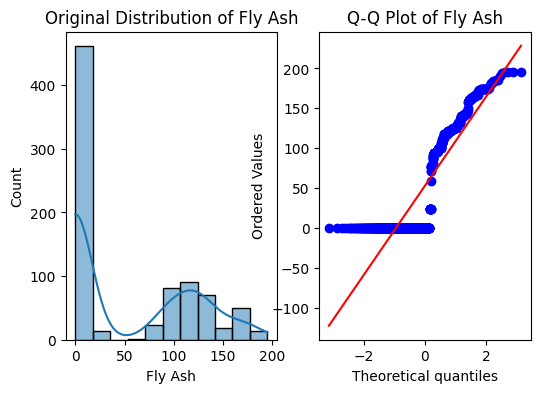

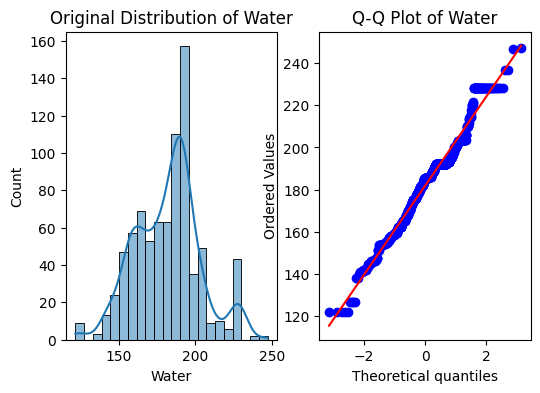

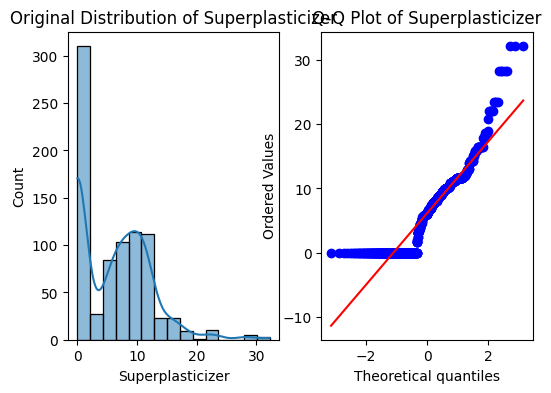

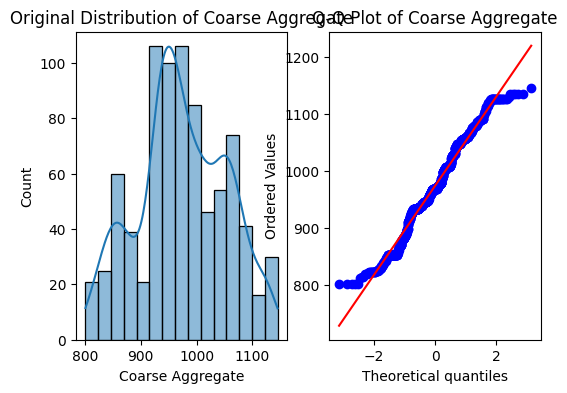

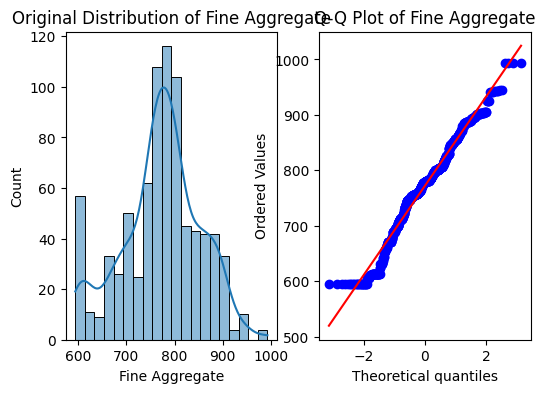

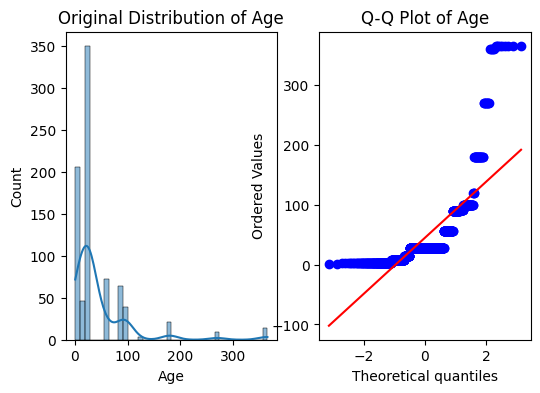

In [13]:
for col in X_train.columns:
    plt.figure(figsize=(6, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(X_train[col], kde=True)
    plt.title(f'Original Distribution of {col}')

    plt.subplot(1, 2, 2)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {col}')

    plt.show()
    

In [14]:
# Applying BOX_COX TRANSFORMATION
pt = PowerTransformer(method='box-cox')
X_train_boxcox = pt.fit_transform(X_train + 0.000001)
X_test_boxcox = pt.transform(X_test + 0.000001)

# this will result in numpy array so we need to convert it back to dataframe for 2 resons
# 1. to check the distribution of the data after transformation
#2 . to regain the column names for future use
X_train_boxcox = pd.DataFrame(X_train_boxcox, columns=X_train.columns)
X_test_boxcox = pd.DataFrame(X_test_boxcox, columns=X_test.columns)


In [15]:
# applying linear regression now

lr = LinearRegression()
lr.fit(X_train_boxcox, y_train)
y_pred_boxcox = lr.predict(X_test_boxcox)
print("R2 score with Box-Cox transformation: ", r2_score(y_test, y_pred_boxcox))


R2 score with Box-Cox transformation:  0.8047825011028632


In [16]:
# using cross val score

pt = PowerTransformer(method='box-cox')
X_boxcox = pt.fit_transform(X + 0.000001)
X_boxcox = pd.DataFrame(X_boxcox, columns=X.columns)
lr = LinearRegression()
print("Cross val score with Box-Cox transformation: ", np.mean(cross_val_score(lr, X_boxcox, y, cv=10, scoring='r2')))

Cross val score with Box-Cox transformation:  0.6466764736216228


C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_boxcox[col], kde=True)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


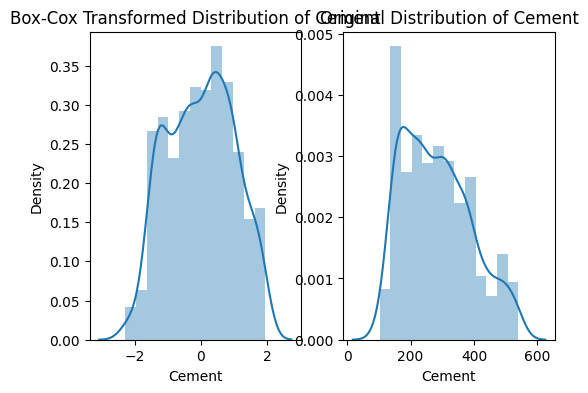

C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_boxcox[col], kde=True)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


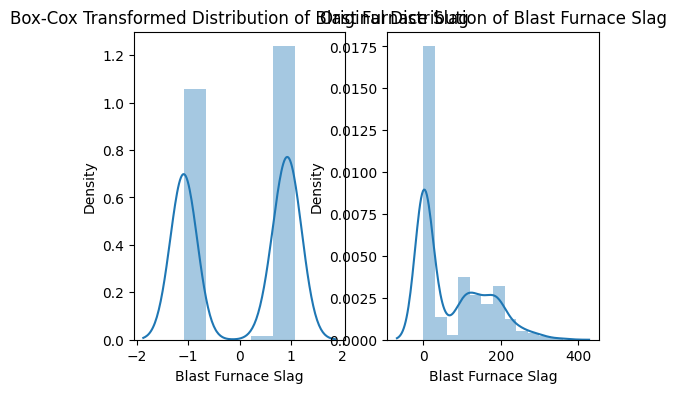

C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_boxcox[col], kde=True)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


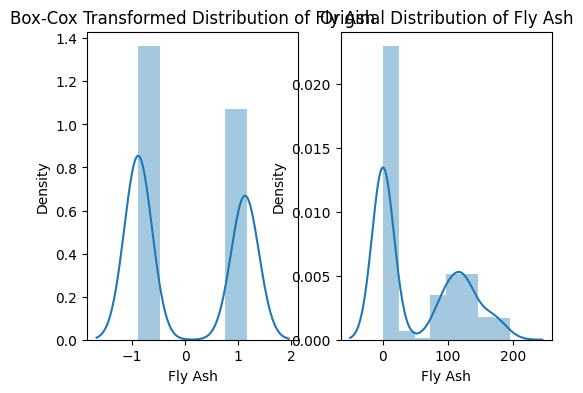

C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_boxcox[col], kde=True)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


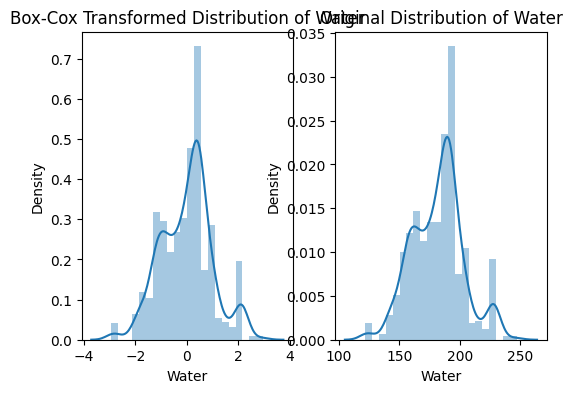

C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_boxcox[col], kde=True)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


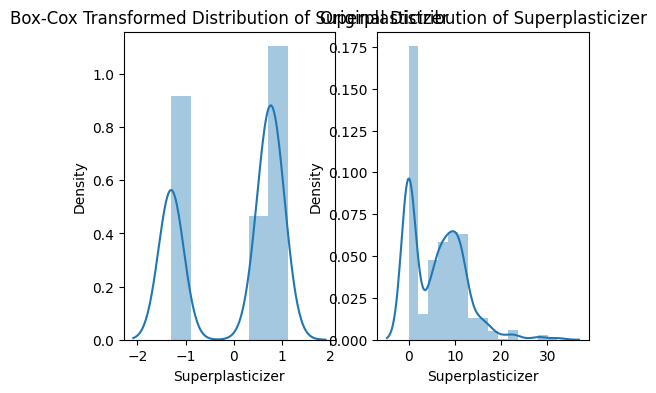

C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_boxcox[col], kde=True)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


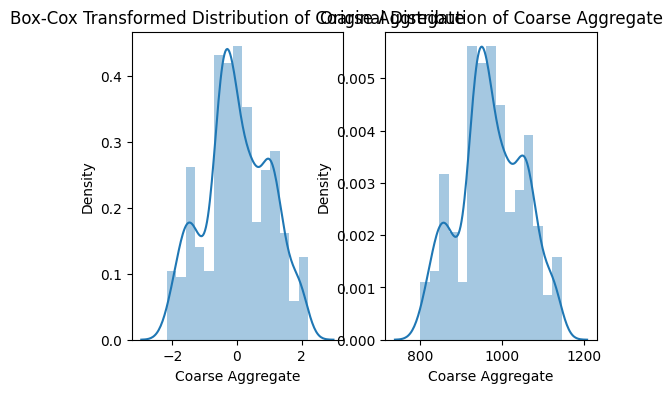

C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_boxcox[col], kde=True)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


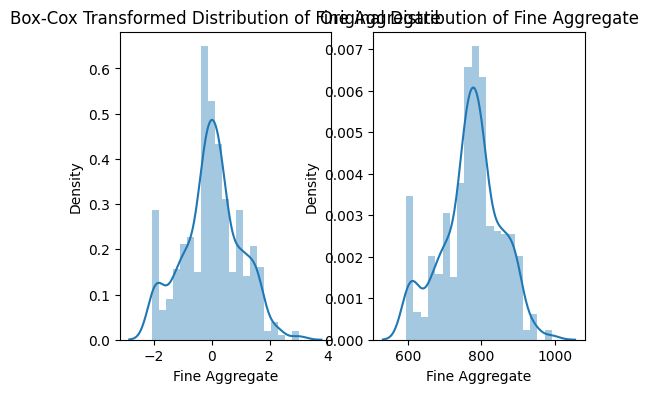

C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_boxcox[col], kde=True)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_28684\699662275.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


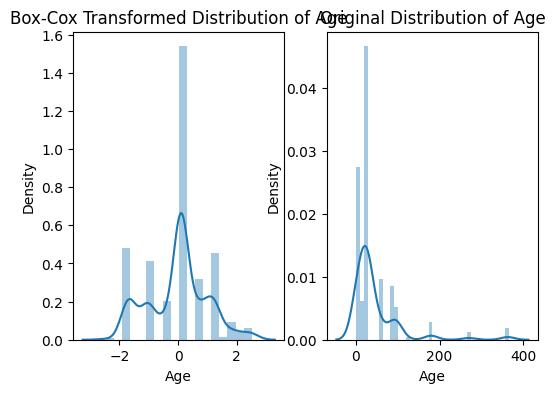

In [17]:
# before and after comparison for box cox
for col in X_train_boxcox.columns:
    plt.figure(figsize=(6, 4))
    plt.subplot(1, 2, 1)
    sns.distplot(X_train_boxcox[col], kde=True)
    plt.title(f'Box-Cox Transformed Distribution of {col}')
    

    plt.subplot(1, 2, 2)
    sns.distplot(X_train[col], kde=True)
    plt.title(f'Original Distribution of {col}')
    plt.show()

In [19]:
# Applying YEO-JOHN TRANSFORMATION
pt = PowerTransformer(method='yeo-johnson')
X_train_yeojohn = pt.fit_transform(X_train)
X_test_yeojohn = pt.transform(X_test)

# converting back to dataframe
X_train_yeojohn = pd.DataFrame(X_train_yeojohn, columns=X_train.columns)
X_test_yeojohn = pd.DataFrame(X_test_yeojohn, columns=X_test.columns)

lr = LinearRegression()
lr.fit(X_train_yeojohn, y_train)
y_pred_yeojohn = lr.predict(X_test_yeojohn)
print("R2 score with Yeo-Johnson transformation: ", r2_score(y_test, y_pred_yeojohn))

print(pt.lambdas_)

R2 score with Yeo-Johnson transformation:  0.8161906511066099
[ 0.17434764  0.01571519 -0.16144653  0.77130664  0.25393481  1.1300501
  1.78309989  0.0198852 ]


In [20]:
# using cross val score

pt = PowerTransformer(method='yeo-johnson')
X_yeo = pt.fit_transform(X + 0.000001)
X_yeo = pd.DataFrame(X_yeo, columns=X.columns)
lr = LinearRegression()
print("Cross val score with Box-Cox transformation: ", np.mean(cross_val_score(lr, X_yeo, y, cv=10, scoring='r2')))

Cross val score with Box-Cox transformation:  0.6586548667423514
